# 🚗 Cars24 Used Cars — Exploratory Data Analysis (EDA)

**Project:** Cars24 Used Cars Data Analysis  
**Focus Areas:** City/Area-wise Analysis & Brand-wise Analysis

This notebook performs:
- Dataset overview
- Data quality checks
- City-wise analysis
- Brand-wise analysis
- Fuel & transmission analysis
- Price and KM analysis
- Price vs KM / Car Age relationships
- Top models
- KPI summary
- Business insights

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Check current Jupyter folder
print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

# Load Cars24 dataset
df = pd.read_csv("Cars24_Raw_data.csv")

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Current folder:
C:\Users\vasav\Webscrapping proj

Files in current folder:
['.ipynb_checkpoints', 'Cars24_EDA.ipynb', 'Cars24_EDA_Complete_Presentation.ipynb', 'Cars24_Raw_data.csv']

Dataset loaded successfully!
Shape: (2004, 14)


,listing_url,car_name,brand,model,manufacturing_year,body_type,fuel_type,transmission,price_numeric,price_currency,km_driven,source_website,scraped_date,City
0,https://www.cars24.com/buy-used-audi-a4-2021-c...,2021 Audi A4 40 TFSI TECHNOLOGY,Audi,A4,2021,Sedan,Petrol,Automatic,2524340,INR,62836,Cars24,21-09-2026,Bangalore
1,https://www.cars24.com/buy-used-audi-a4-2024-c...,2024 Audi A4 40 TFSI PREMIUM PLUS,Audi,A4,2024,Sedan,Petrol,Automatic,3121340,INR,11198,Cars24,21-09-2026,Gurgaon
2,https://www.cars24.com/buy-used-audi-a6-2014-c...,2014 Audi A6 2.0 TDI PREMIUM PLUS,Audi,A6,2014,Sedan,Diesel,Automatic,594500,INR,110048,Cars24,21-09-2026,Mohali
3,https://www.cars24.com/buy-used-audi-q5-2019-c...,2019 Audi Q5 40 TDI PREMIUM PLUS,Audi,Q5,2019,SUV,Diesel,Automatic,2675340,INR,77788,Cars24,21-09-2026,Mumbai
4,https://www.cars24.com/buy-used-bmw-x1-2014-ca...,2014 BMW X1 SDRIVE 20D X LINE,BMW,X1,2014,SUV,Diesel,Automatic,760000,INR,99855,Cars24,21-09-2026,Mohali


## 1. Dataset Overview

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Rows: 2004
Columns: 14

Column Names:
['listing_url', 'car_name', 'brand', 'model', 'manufacturing_year', 'body_type', 'fuel_type', 'transmission', 'price_numeric', 'price_currency', 'km_driven', 'source_website', 'scraped_date', 'City']

Data Types:


listing_url           object
car_name              object
brand                 object
model                 object
manufacturing_year     int64
body_type             object
fuel_type             object
transmission          object
price_numeric          int64
price_currency        object
km_driven              int64
source_website        object
scraped_date          object
City                  object
dtype: object


First 5 Rows:


,listing_url,car_name,brand,model,manufacturing_year,body_type,fuel_type,transmission,price_numeric,price_currency,km_driven,source_website,scraped_date,City
0,https://www.cars24.com/buy-used-audi-a4-2021-c...,2021 Audi A4 40 TFSI TECHNOLOGY,Audi,A4,2021,Sedan,Petrol,Automatic,2524340,INR,62836,Cars24,21-09-2026,Bangalore
1,https://www.cars24.com/buy-used-audi-a4-2024-c...,2024 Audi A4 40 TFSI PREMIUM PLUS,Audi,A4,2024,Sedan,Petrol,Automatic,3121340,INR,11198,Cars24,21-09-2026,Gurgaon
2,https://www.cars24.com/buy-used-audi-a6-2014-c...,2014 Audi A6 2.0 TDI PREMIUM PLUS,Audi,A6,2014,Sedan,Diesel,Automatic,594500,INR,110048,Cars24,21-09-2026,Mohali
3,https://www.cars24.com/buy-used-audi-q5-2019-c...,2019 Audi Q5 40 TDI PREMIUM PLUS,Audi,Q5,2019,SUV,Diesel,Automatic,2675340,INR,77788,Cars24,21-09-2026,Mumbai
4,https://www.cars24.com/buy-used-bmw-x1-2014-ca...,2014 BMW X1 SDRIVE 20D X LINE,BMW,X1,2014,SUV,Diesel,Automatic,760000,INR,99855,Cars24,21-09-2026,Mohali


In [44]:
print("Missing Values:")
display(df.isnull().sum().sort_values(ascending=False))

print("Duplicate Rows:", df.duplicated().sum())

if 'listing_url' in df.columns:
    print("Duplicate Listing URLs:", df['listing_url'].duplicated().sum())

Missing Values:


listing_url           0
car_name              0
brand                 0
model                 0
manufacturing_year    0
body_type             0
fuel_type             0
transmission          0
price_numeric         0
price_currency        0
km_driven             0
source_website        0
scraped_date          0
City                  0
dtype: int64

Duplicate Rows: 0
Duplicate Listing URLs: 0


## 2. Prepare Analysis Columns

In [45]:
# Make a copy so the raw dataset is never modified
eda = df.copy()

# Standardize useful analysis columns based on the Cars24 raw dataset
if 'price_numeric' in eda.columns:
    eda['Price_INR'] = pd.to_numeric(eda['price_numeric'], errors='coerce')

if 'km_driven' in eda.columns:
    eda['KM'] = pd.to_numeric(eda['km_driven'], errors='coerce')

if 'manufacturing_year' in eda.columns:
    eda['Year'] = pd.to_numeric(eda['manufacturing_year'], errors='coerce')

# Create car age using the latest year available in the dataset
if 'Year' in eda.columns:
    current_year = int(eda['Year'].max())
    eda['Car_Age'] = current_year - eda['Year']

print("Analysis columns ready.")
display(eda.head())

Analysis columns ready.


,listing_url,car_name,brand,model,manufacturing_year,body_type,fuel_type,transmission,price_numeric,price_currency,km_driven,source_website,scraped_date,City,Price_INR,KM,Year,Car_Age
0,https://www.cars24.com/buy-used-audi-a4-2021-c...,2021 Audi A4 40 TFSI TECHNOLOGY,Audi,A4,2021,Sedan,Petrol,Automatic,2524340,INR,62836,Cars24,21-09-2026,Bangalore,2524340,62836,2021,5
1,https://www.cars24.com/buy-used-audi-a4-2024-c...,2024 Audi A4 40 TFSI PREMIUM PLUS,Audi,A4,2024,Sedan,Petrol,Automatic,3121340,INR,11198,Cars24,21-09-2026,Gurgaon,3121340,11198,2024,2
2,https://www.cars24.com/buy-used-audi-a6-2014-c...,2014 Audi A6 2.0 TDI PREMIUM PLUS,Audi,A6,2014,Sedan,Diesel,Automatic,594500,INR,110048,Cars24,21-09-2026,Mohali,594500,110048,2014,12
3,https://www.cars24.com/buy-used-audi-q5-2019-c...,2019 Audi Q5 40 TDI PREMIUM PLUS,Audi,Q5,2019,SUV,Diesel,Automatic,2675340,INR,77788,Cars24,21-09-2026,Mumbai,2675340,77788,2019,7
4,https://www.cars24.com/buy-used-bmw-x1-2014-ca...,2014 BMW X1 SDRIVE 20D X LINE,BMW,X1,2014,SUV,Diesel,Automatic,760000,INR,99855,Cars24,21-09-2026,Mohali,760000,99855,2014,12


## 3. Numerical Summary

In [46]:
numeric_cols = [c for c in ['Price_INR', 'KM', 'Year', 'Car_Age'] if c in eda.columns]
display(eda[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Price_INR,2004.0,555866.157186,360127.626838,87000.0,317811.00,482512.5,705687.0,3883340.0
KM,2004.0,65057.941118,32305.074080,597.0,42584.25,62534.5,83498.0,274771.0
Year,2004.0,2019.146707,3.346735,2010.0,2017.00,2019.0,2022.0,2026.0
Car_Age,2004.0,6.853293,3.346735,0.0,4.00,7.0,9.0,16.0


## 4. City-wise Analysis

,Number_of_Cars
City,
Chandigarh,123
Bangalore,102
Hyderabad,100
Surat,100
Gurgaon,99
Ahmedabad,99
Noida,98
Vadodara,98
Bhopal,98


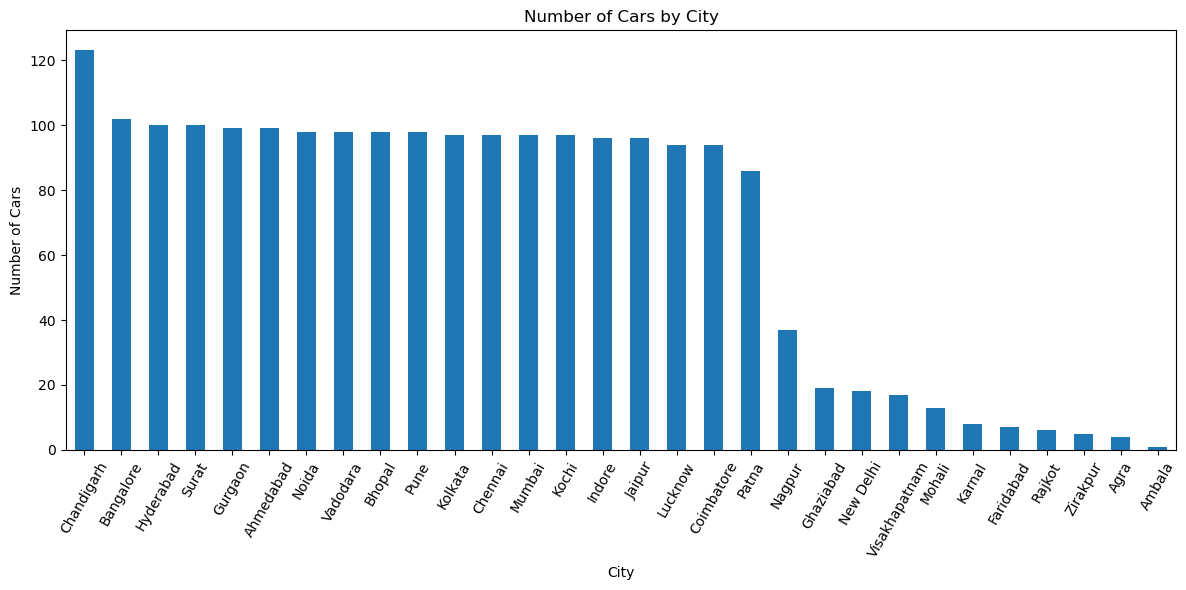

In [47]:
if 'City' in eda.columns:
    city_counts = eda['City'].value_counts().sort_values(ascending=False)
    display(city_counts.to_frame('Number_of_Cars'))

    plt.figure(figsize=(12,6))
    city_counts.plot(kind='bar')
    plt.title('Number of Cars by City')
    plt.xlabel('City')
    plt.ylabel('Number of Cars')
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()
else:
    print("City column not found.")

In [48]:
#Top 10 cities
city_counts = df['City'].value_counts().head(10)

print(city_counts)

City
Chandigarh    123
Bangalore     102
Hyderabad     100
Surat         100
Gurgaon        99
Ahmedabad      99
Noida          98
Vadodara       98
Bhopal         98
Pune           98
Name: count, dtype: int64


,mean,median
City,,
Coimbatore,739510.914894,659636.0
Bangalore,667149.715686,578144.0
Gurgaon,649921.676768,527916.0
Chandigarh,649633.276423,568576.0
Hyderabad,640804.310000,554878.0
Pune,638844.040816,503236.0
Chennai,609501.257732,559480.0
Ghaziabad,602912.421053,609826.0
Rajkot,597595.166667,606890.0


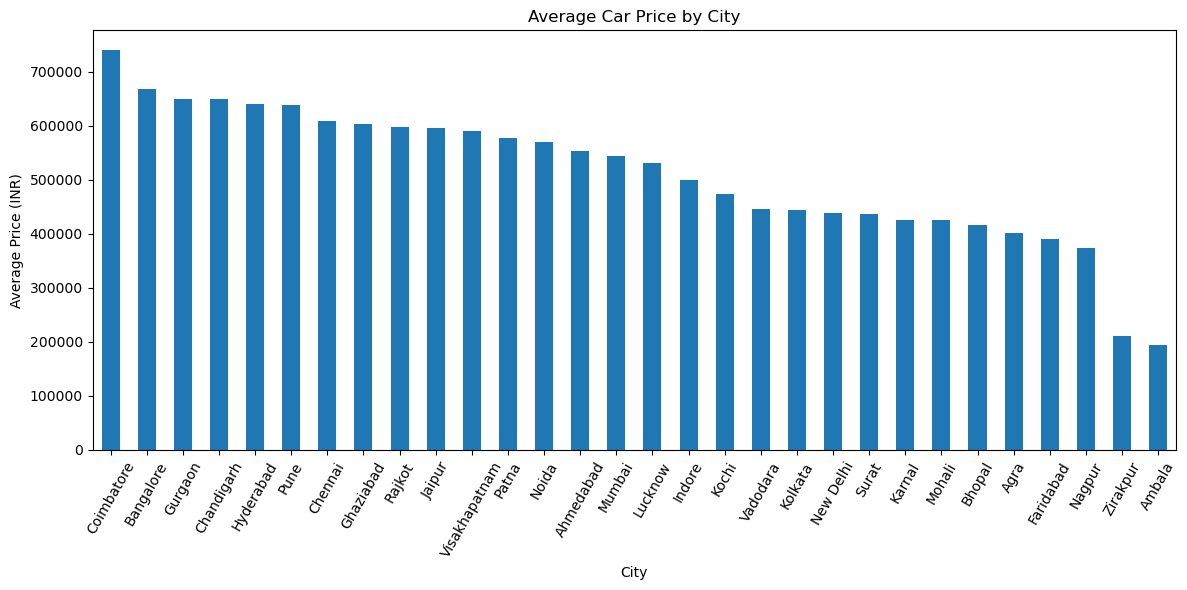

In [49]:
if {'City','Price_INR'}.issubset(eda.columns):
    city_price = eda.groupby('City')['Price_INR'].agg(['mean','median']).sort_values('mean', ascending=False)
    display(city_price)

    city_price['mean'].plot(kind='bar', figsize=(12,6))
    plt.title('Average Car Price by City')
    plt.xlabel('City')
    plt.ylabel('Average Price (INR)')
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

,Average_KM
City,
Zirakpur,90427.600000
Nagpur,87728.459459
Mohali,87598.076923
Visakhapatnam,82400.647059
Ambala,78747.000000
Vadodara,74107.346939
Bhopal,72774.938776
Coimbatore,72142.510638
Pune,70440.295918


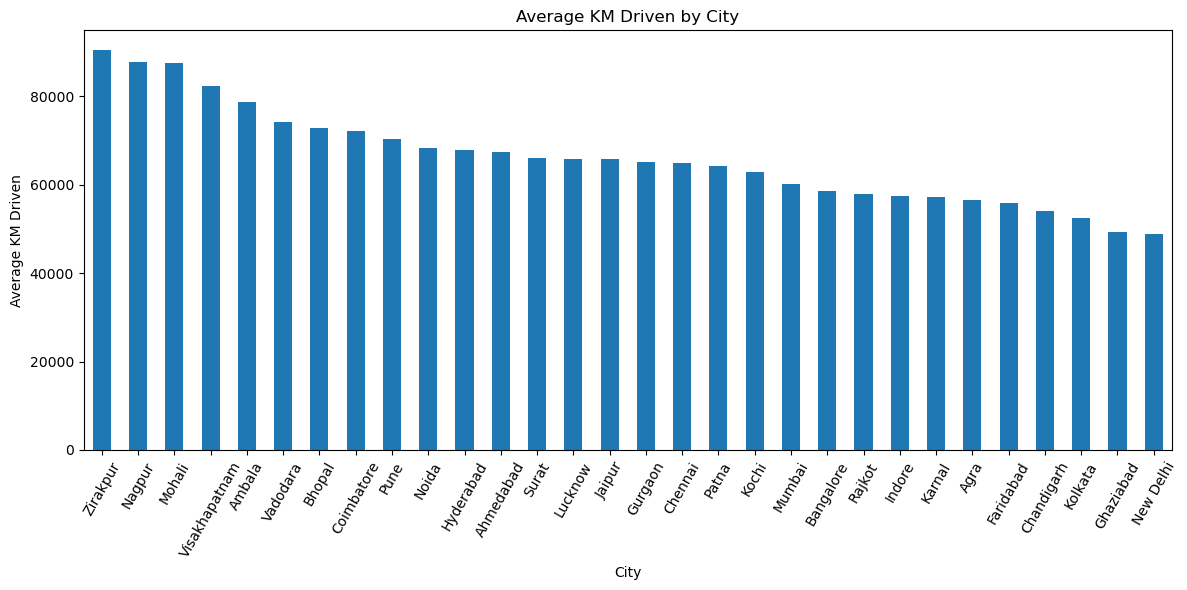

In [50]:
if {'City','KM'}.issubset(eda.columns):
    city_km = eda.groupby('City')['KM'].mean().sort_values(ascending=False)
    display(city_km.to_frame('Average_KM'))

    city_km.plot(kind='bar', figsize=(12,6))
    plt.title('Average KM Driven by City')
    plt.xlabel('City')
    plt.ylabel('Average KM Driven')
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

## 5. Fuel Type Analysis

,Number_of_Cars
fuel_type,
Petrol,1585
Diesel,289
CNG,123
Hybrid,7


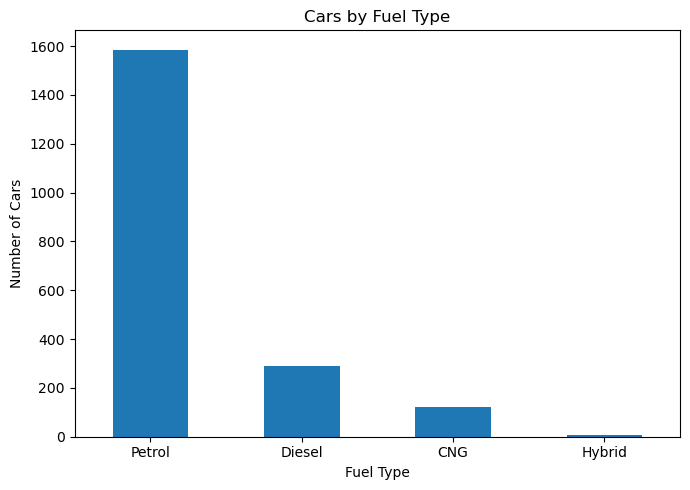

In [51]:
if 'fuel_type' in eda.columns:
    fuel_counts = eda['fuel_type'].value_counts()
    display(fuel_counts.to_frame('Number_of_Cars'))

    plt.figure(figsize=(7,5))
    fuel_counts.plot(kind='bar')
    plt.title('Cars by Fuel Type')
    plt.xlabel('Fuel Type')
    plt.ylabel('Number of Cars')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

fuel_type,CNG,Diesel,Hybrid,Petrol
City,,,,
Agra,0,0,0,4
Ahmedabad,13,18,0,68
Ambala,0,0,0,1
Bangalore,0,12,0,90
Bhopal,3,26,0,69
Chandigarh,7,19,1,96
Chennai,0,11,0,86
Coimbatore,1,20,2,71
Faridabad,0,0,0,7


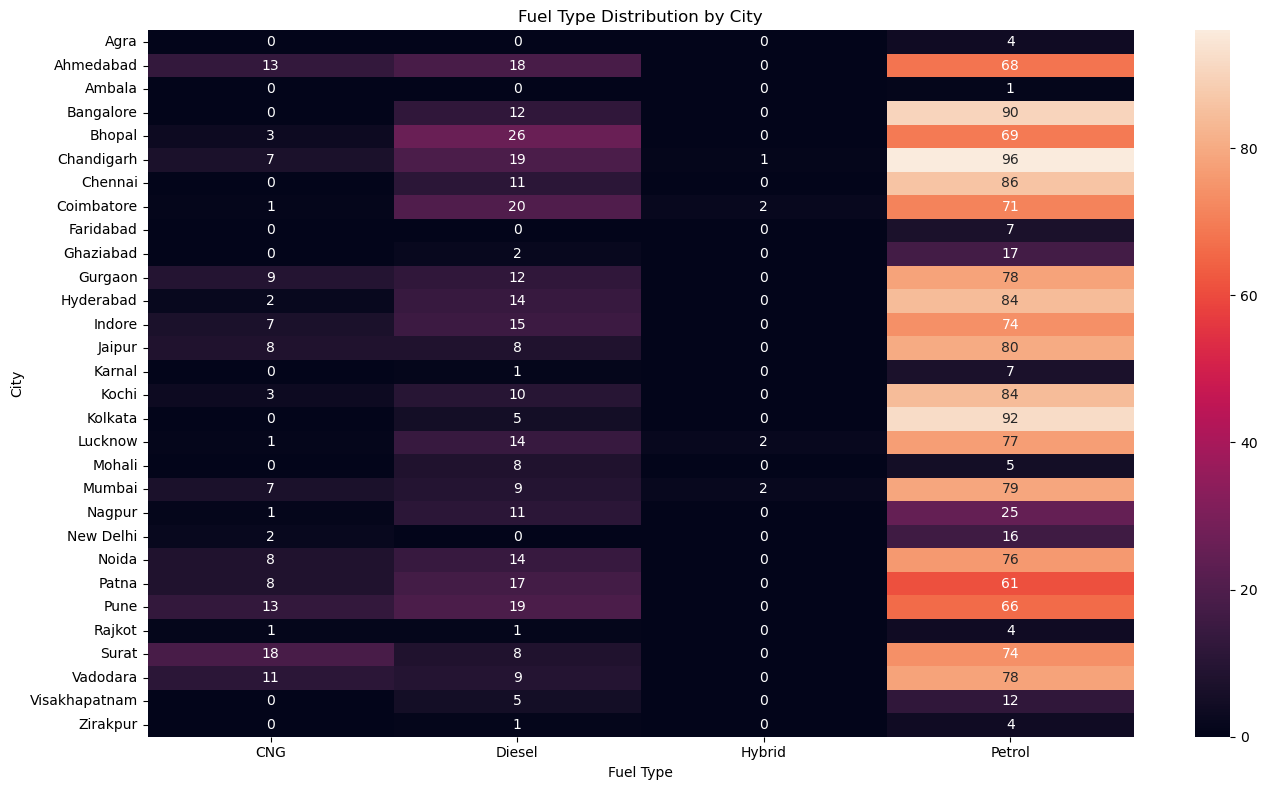

In [52]:
if {'City','fuel_type'}.issubset(eda.columns):
    city_fuel = pd.crosstab(eda['City'], eda['fuel_type'])
    display(city_fuel)

    plt.figure(figsize=(14,8))
    sns.heatmap(city_fuel, annot=True, fmt='g')
    plt.title('Fuel Type Distribution by City')
    plt.xlabel('Fuel Type')
    plt.ylabel('City')
    plt.tight_layout()
    plt.show()

## 6. Transmission Analysis

,Number_of_Cars
transmission,
Manual,1559
Automatic,445


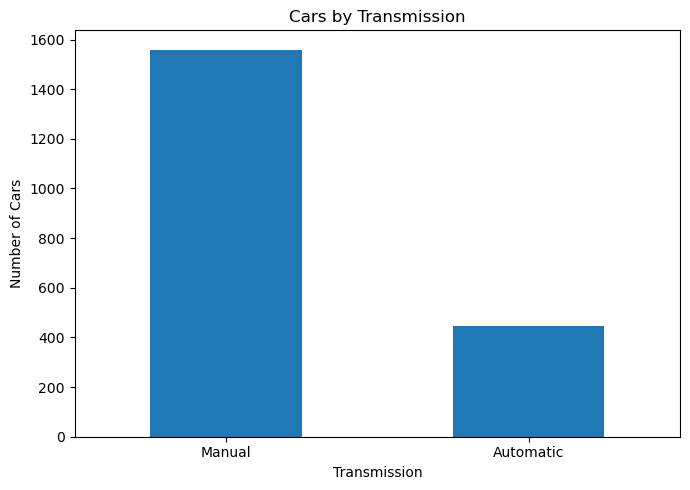

In [53]:
if 'transmission' in eda.columns:
    transmission_counts = eda['transmission'].value_counts()
    display(transmission_counts.to_frame('Number_of_Cars'))

    plt.figure(figsize=(7,5))
    transmission_counts.plot(kind='bar')
    plt.title('Cars by Transmission')
    plt.xlabel('Transmission')
    plt.ylabel('Number of Cars')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

transmission,Automatic,Manual
City,,
Agra,0,4
Ahmedabad,20,79
Ambala,0,1
Bangalore,24,78
Bhopal,10,88
Chandigarh,31,92
Chennai,34,63
Coimbatore,29,65
Faridabad,0,7


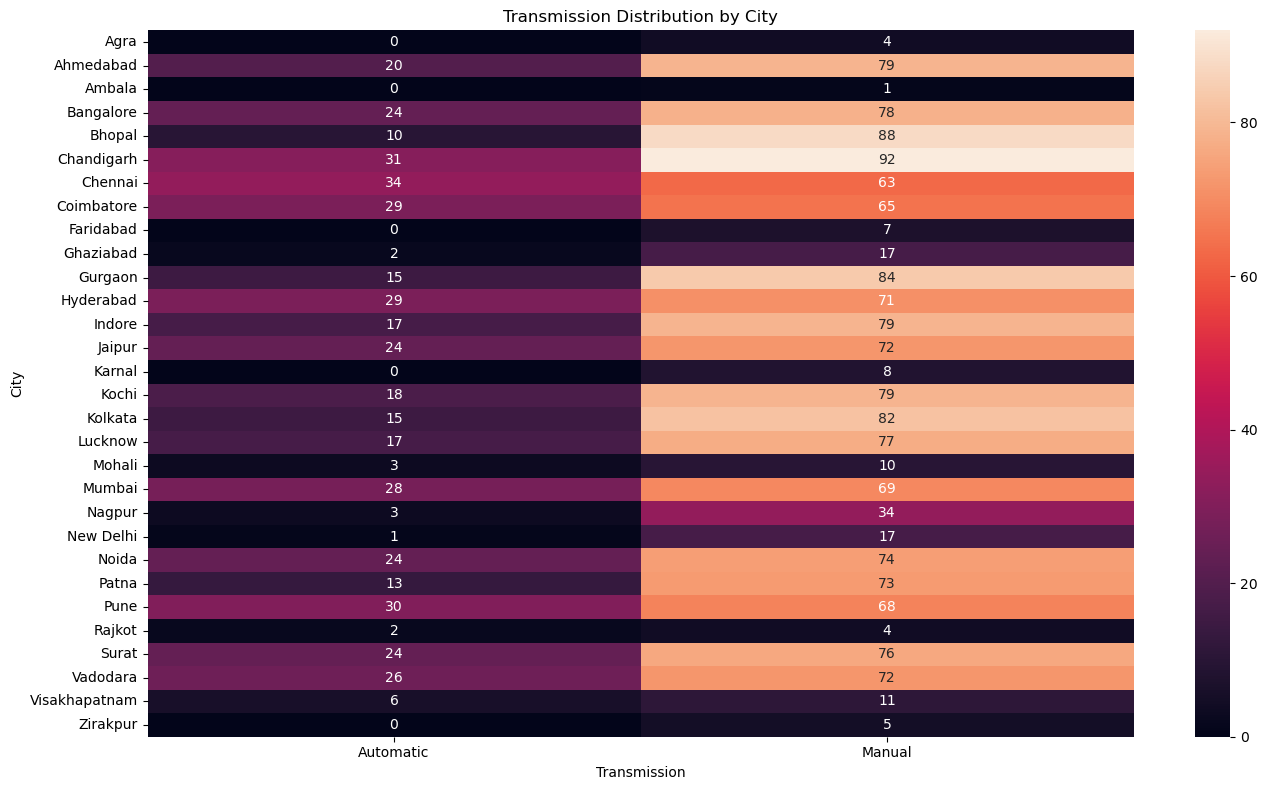

In [18]:
if {'City','transmission'}.issubset(eda.columns):
    city_transmission = pd.crosstab(eda['City'], eda['transmission'])
    display(city_transmission)

    plt.figure(figsize=(14,8))
    sns.heatmap(city_transmission, annot=True, fmt='g')
    plt.title('Transmission Distribution by City')
    plt.xlabel('Transmission')
    plt.ylabel('City')
    plt.tight_layout()
    plt.show()

## 7. Brand-wise Analysis

,Number_of_Cars
brand,
Maruti,477
Hyundai,330
Tata,262
Renault,142
Mahindra,105
Volkswagen,92
KIA,89
Honda,83
Ford,78


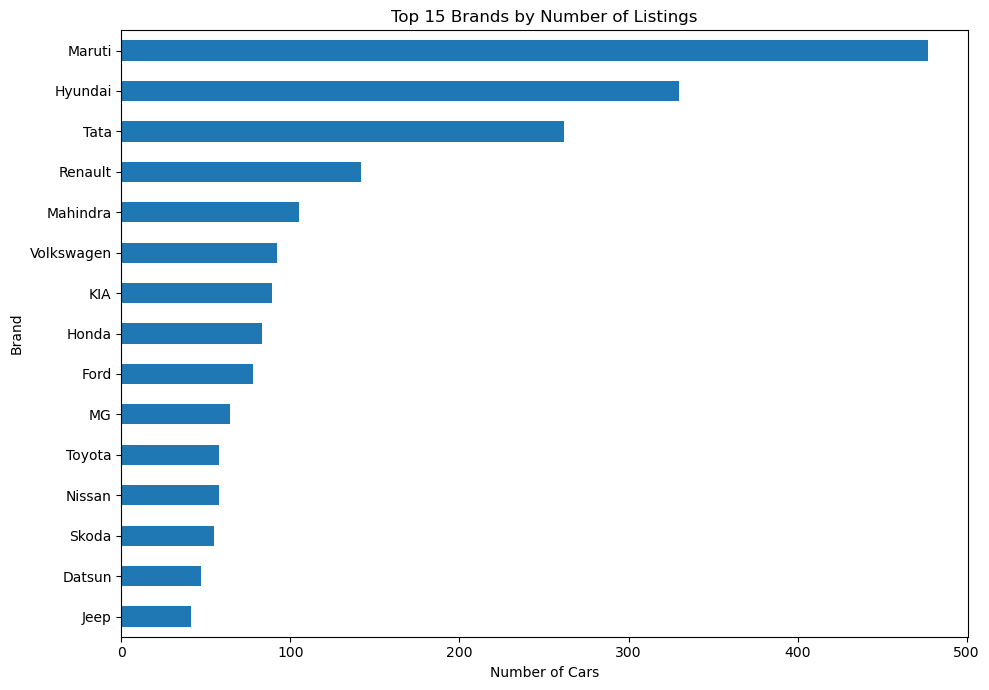

In [54]:
if 'brand' in eda.columns:
    top_brands = eda['brand'].value_counts().head(15)
    display(top_brands.to_frame('Number_of_Cars'))

    top_brands.sort_values().plot(kind='barh', figsize=(10,7))
    plt.title('Top 15 Brands by Number of Listings')
    plt.xlabel('Number of Cars')
    plt.ylabel('Brand')
    plt.tight_layout()
    plt.show()

,mean,median,count
brand,,,
Maruti,454849.371069,412296.0,477
Hyundai,491715.642424,436268.5,330
Tata,560433.099237,529758.0,262
Renault,314826.795775,284377.0,142
Mahindra,853316.466667,726840.0,105
Volkswagen,523636.228261,390116.0,92
KIA,821388.213483,785636.0,89
Honda,384281.240964,381320.0,83
Ford,446666.756410,429870.0,78


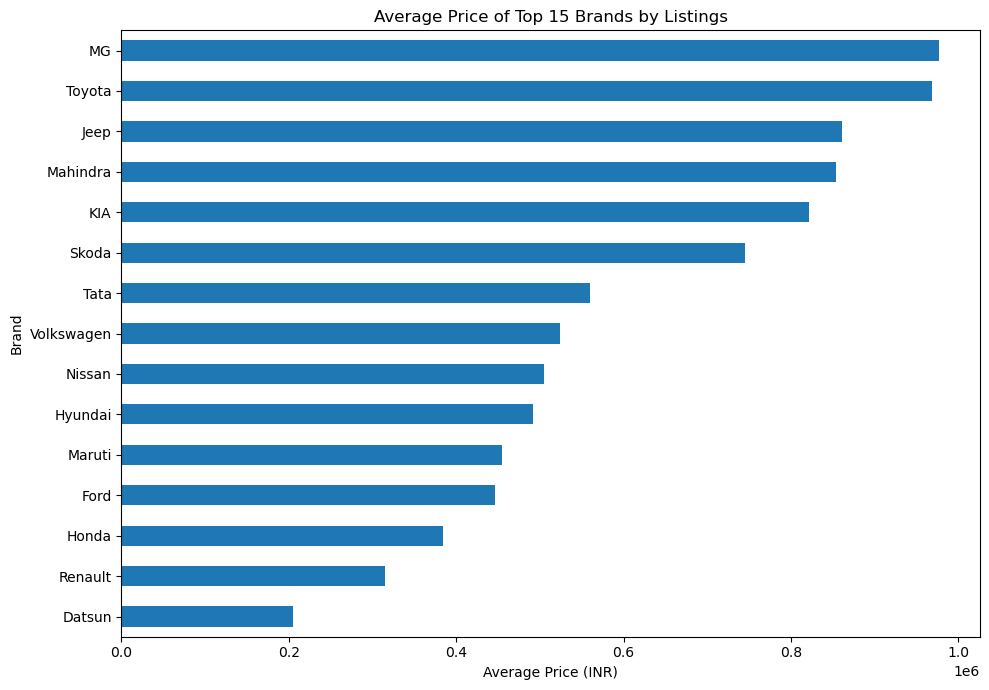

In [55]:
if {'brand','Price_INR'}.issubset(eda.columns):
    brand_price = eda.groupby('brand')['Price_INR'].agg(['mean','median','count'])
    brand_price = brand_price.sort_values('count', ascending=False).head(15)

    display(brand_price)

    brand_price.sort_values('mean')['mean'].plot(kind='barh', figsize=(10,7))
    plt.title('Average Price of Top 15 Brands by Listings')
    plt.xlabel('Average Price (INR)')
    plt.ylabel('Brand')
    plt.tight_layout()
    plt.show()

,mean,median,count
brand,,,
Maruti,63108.706499,60466.0,477
Hyundai,65392.342424,62691.0,330
Tata,60954.374046,58446.5,262
Renault,58083.535211,56707.5,142
Mahindra,72846.561905,66417.0,105
Volkswagen,77536.456522,77926.0,92
KIA,63055.393258,60232.0,89
Honda,76589.204819,72274.0,83
Ford,80124.064103,74812.5,78


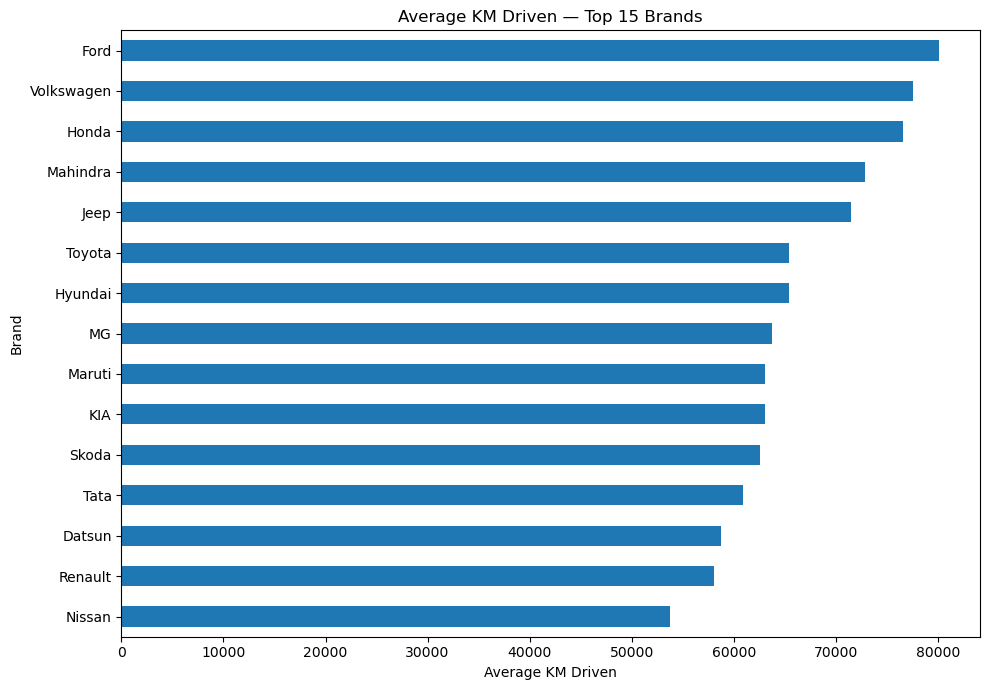

In [56]:
if {'brand','KM'}.issubset(eda.columns):
    brand_km = eda.groupby('brand')['KM'].agg(['mean','median','count'])
    brand_km = brand_km.sort_values('count', ascending=False).head(15)

    display(brand_km)

    brand_km.sort_values('mean')['mean'].plot(kind='barh', figsize=(10,7))
    plt.title('Average KM Driven — Top 15 Brands')
    plt.xlabel('Average KM Driven')
    plt.ylabel('Brand')
    plt.tight_layout()
    plt.show()

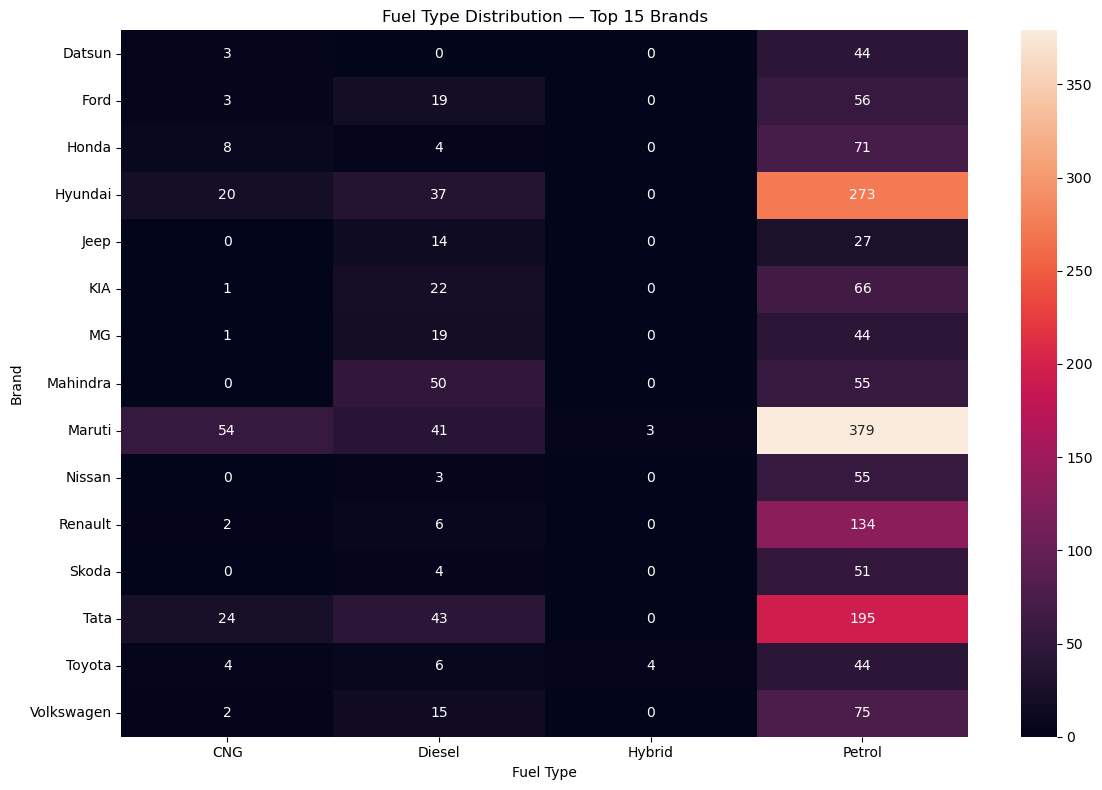

In [57]:
if {'brand','fuel_type'}.issubset(eda.columns):
    brand_fuel = pd.crosstab(eda['brand'], eda['fuel_type'])
    top_brand_names = eda['brand'].value_counts().head(15).index
    brand_fuel = brand_fuel.loc[brand_fuel.index.intersection(top_brand_names)]

    plt.figure(figsize=(12,8))
    sns.heatmap(brand_fuel, annot=True, fmt='g')
    plt.title('Fuel Type Distribution — Top 15 Brands')
    plt.xlabel('Fuel Type')
    plt.ylabel('Brand')
    plt.tight_layout()
    plt.show()

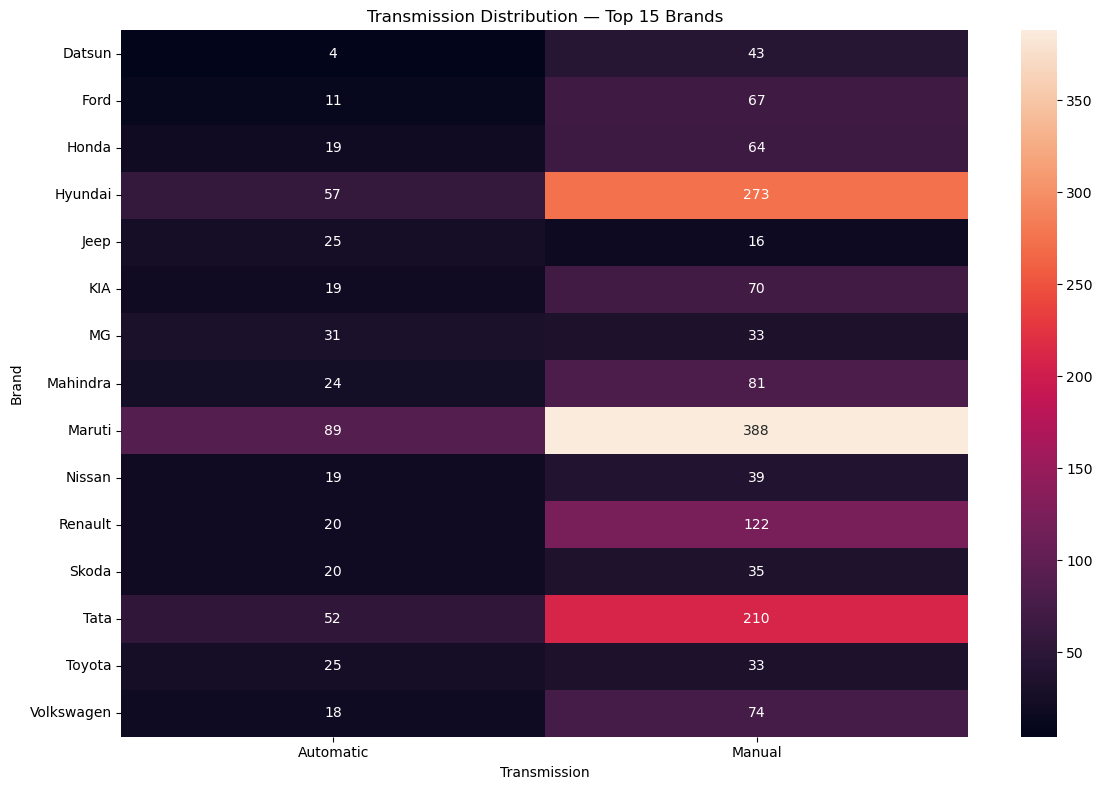

In [58]:
if {'brand','transmission'}.issubset(eda.columns):
    brand_trans = pd.crosstab(eda['brand'], eda['transmission'])
    top_brand_names = eda['brand'].value_counts().head(15).index
    brand_trans = brand_trans.loc[brand_trans.index.intersection(top_brand_names)]

    plt.figure(figsize=(12,8))
    sns.heatmap(brand_trans, annot=True, fmt='g')
    plt.title('Transmission Distribution — Top 15 Brands')
    plt.xlabel('Transmission')
    plt.ylabel('Brand')
    plt.tight_layout()
    plt.show()

## 8. Price Analysis

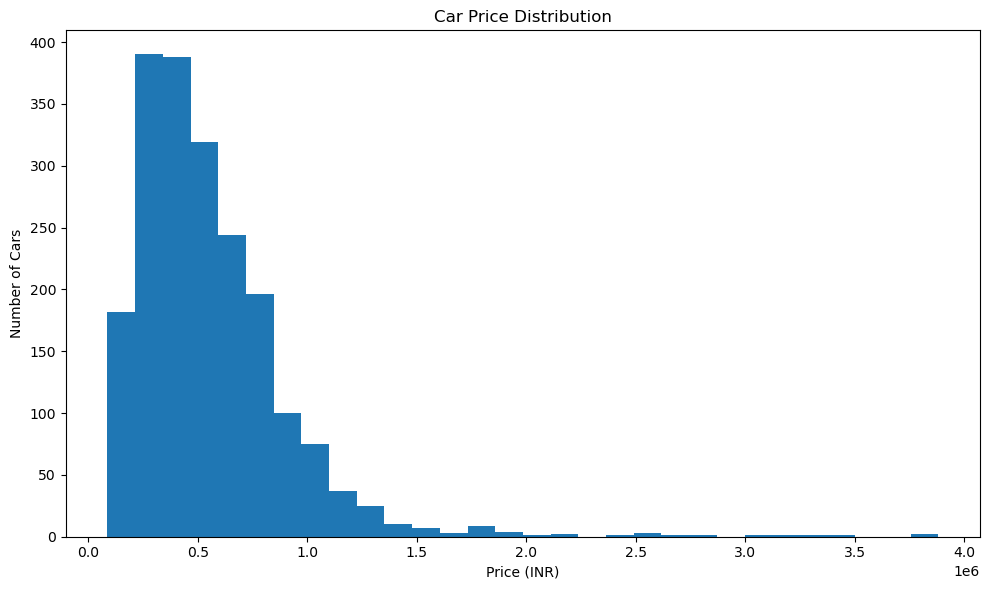

In [59]:
if 'Price_INR' in eda.columns:
    plt.figure(figsize=(10,6))
    plt.hist(eda['Price_INR'].dropna(), bins=30)
    plt.title('Car Price Distribution')
    plt.xlabel('Price (INR)')
    plt.ylabel('Number of Cars')
    plt.tight_layout()
    plt.show()

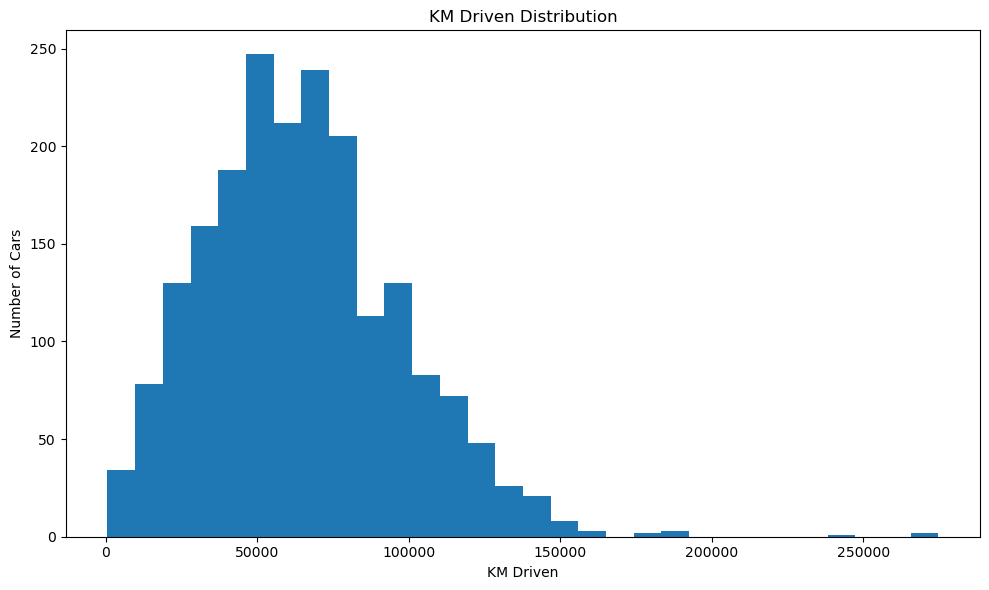

In [60]:
if 'KM' in eda.columns:
    plt.figure(figsize=(10,6))
    plt.hist(eda['KM'].dropna(), bins=30)
    plt.title('KM Driven Distribution')
    plt.xlabel('KM Driven')
    plt.ylabel('Number of Cars')
    plt.tight_layout()
    plt.show()

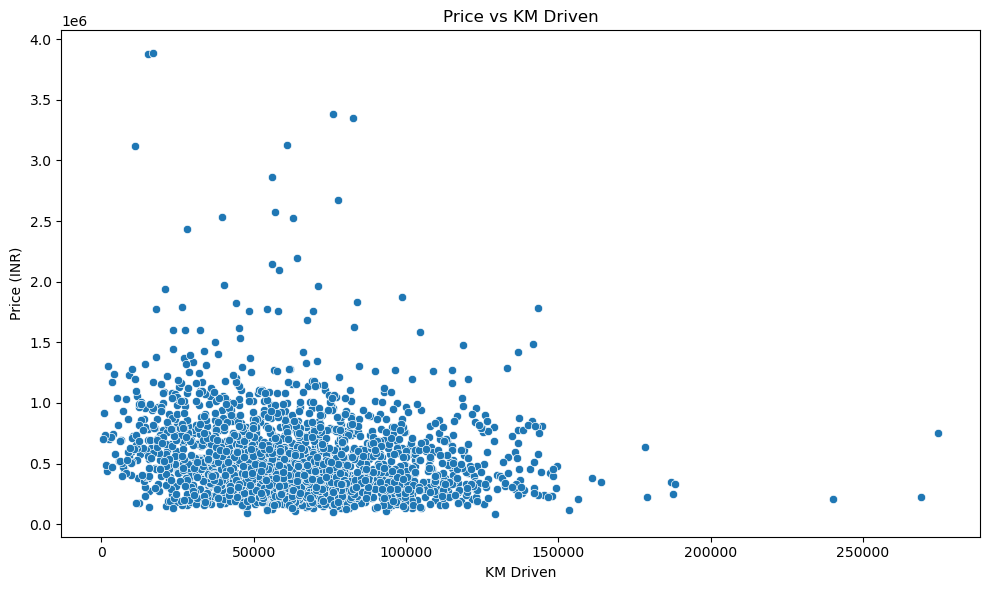

In [61]:
if {'KM','Price_INR'}.issubset(eda.columns):
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=eda, x='KM', y='Price_INR')
    plt.title('Price vs KM Driven')
    plt.xlabel('KM Driven')
    plt.ylabel('Price (INR)')
    plt.tight_layout()
    plt.show()

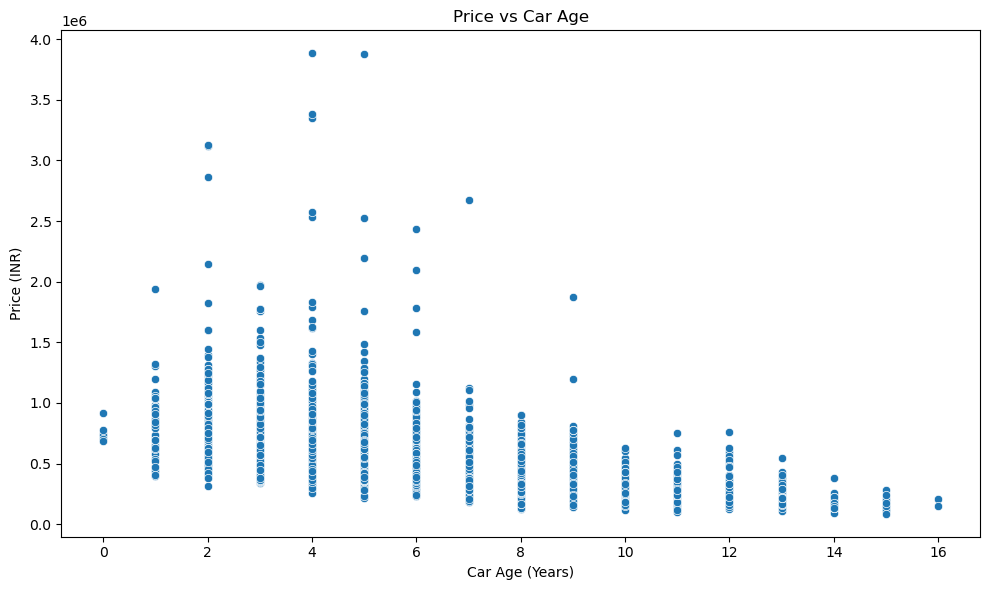

In [62]:
if {'Car_Age','Price_INR'}.issubset(eda.columns):
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=eda, x='Car_Age', y='Price_INR')
    plt.title('Price vs Car Age')
    plt.xlabel('Car Age (Years)')
    plt.ylabel('Price (INR)')
    plt.tight_layout()
    plt.show()

## 9. Top 10 Models

,Number_of_Cars
model,
Kwid,101
Swift,91
NEXON,91
Tiago,73
Grand i10,63
Ecosport,59
Elite i20,54
SELTOS,48
Wagon R 1.0,44


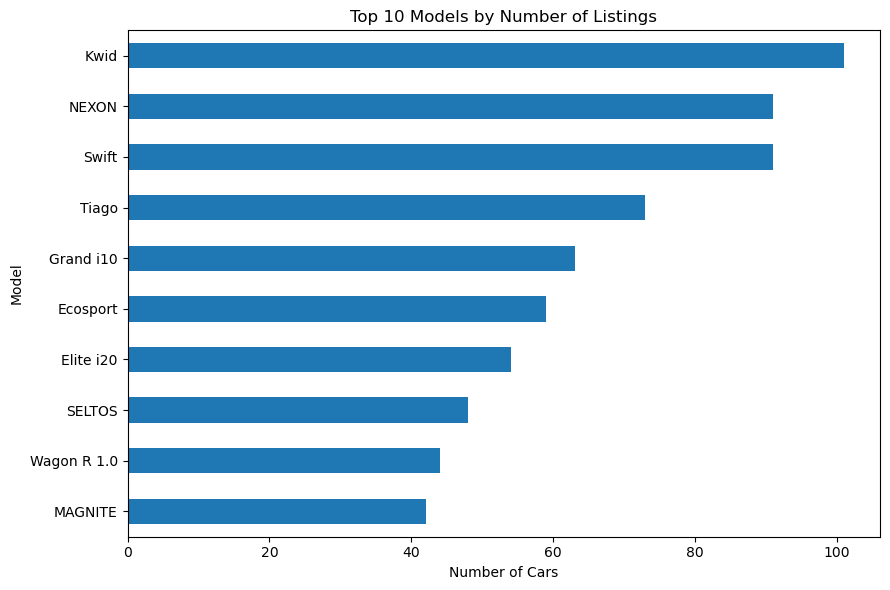

In [63]:
if 'model' in eda.columns:
    top_models = eda['model'].value_counts().head(10)
    display(top_models.to_frame('Number_of_Cars'))

    top_models.sort_values().plot(kind='barh', figsize=(9,6))
    plt.title('Top 10 Models by Number of Listings')
    plt.xlabel('Number of Cars')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.show()

## 10. KPI Summary

In [64]:
kpis = {}

kpis['Total Listings'] = len(eda)

if 'City' in eda.columns:
    kpis['Number of Cities'] = eda['City'].nunique()

if 'brand' in eda.columns:
    kpis['Number of Brands'] = eda['brand'].nunique()

if 'Price_INR' in eda.columns:
    kpis['Average Price'] = eda['Price_INR'].mean()
    kpis['Median Price'] = eda['Price_INR'].median()

if 'KM' in eda.columns:
    kpis['Average KM'] = eda['KM'].mean()

display(pd.Series(kpis, name='Value'))

Total Listings        2004.000000
Number of Cities        30.000000
Number of Brands        23.000000
Average Price       555866.157186
Median Price        482512.500000
Average KM           65057.941118
Name: Value, dtype: float64

## 11. Business Questions to Answer

After running the notebook, use the actual results to answer:

### City / Area Analysis
1. Which city has the highest number of Cars24 listings?
2. Which cities have higher average used-car prices?
3. Which cities have higher average KM driven?
4. What fuel types dominate across cities?
5. How does automatic/manual preference vary by city?

### Brand Analysis
1. Which brands have the most listings?
2. Which brands have higher average prices?
3. Which brands have higher average KM driven?
4. What fuel types are common for major brands?
5. What transmission types are common for major brands?

### Price Behaviour
1. How are used-car prices distributed?
2. Is there a relationship between KM driven and price?
3. Is there a relationship between car age and price?

> **Important:** Write insights only after checking the actual values and charts. Avoid unsupported assumptions.

## 12. Next Step

After completing this EDA:

**EDA → Data-backed Insights → Power BI Dashboard → Final Presentation**

Recommended dashboard pages:
1. Executive Summary
2. City / Area Analysis
3. Brand Analysis

# 10. Presentation EDA — Univariate, Bivariate & Multivariate Analysis

This section adds presentation-ready EDA outputs to the existing Cars24 analysis.

**Univariate:** one variable at a time  
**Bivariate:** relationship between two variables  
**Multivariate:** relationships among multiple variables

The analysis uses the existing `eda` DataFrame and does not modify the raw dataset.


## 10.1 Univariate Analysis — Distribution of Key Variables

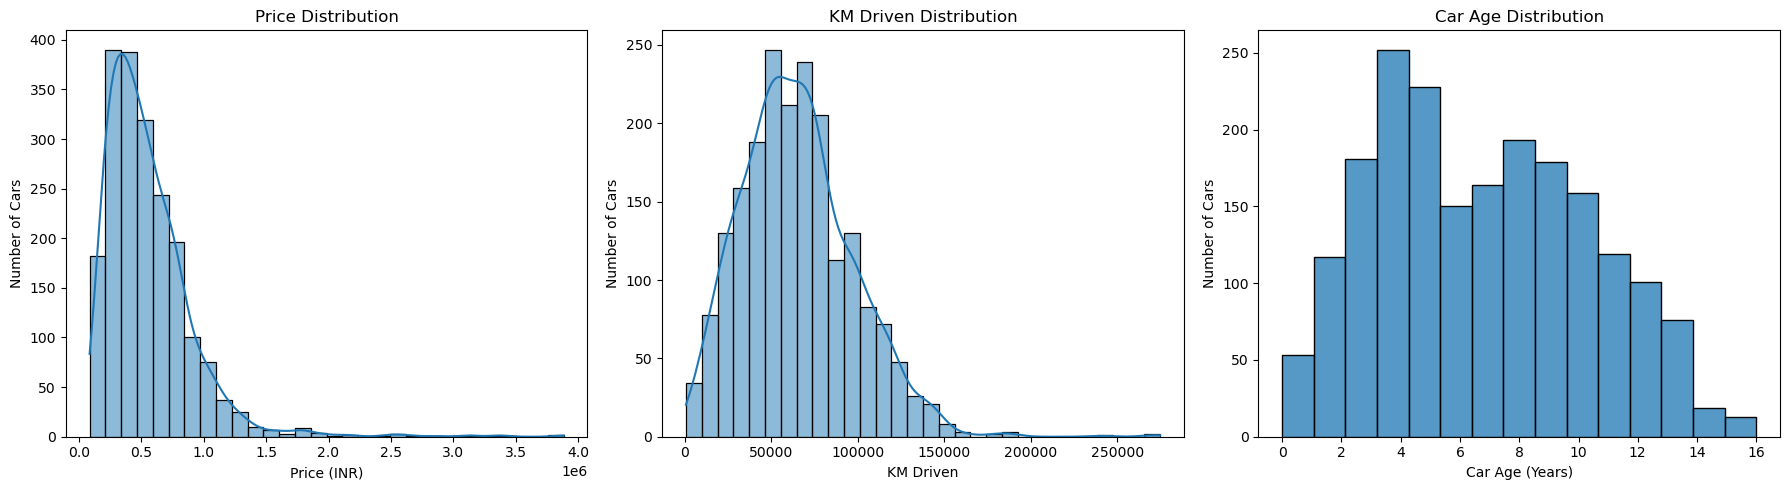

In [30]:
# Univariate Analysis: Price, KM Driven and Car Age
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(eda['Price_INR'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Number of Cars')

sns.histplot(eda['KM'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('KM Driven Distribution')
axes[1].set_xlabel('KM Driven')
axes[1].set_ylabel('Number of Cars')

sns.histplot(eda['Car_Age'], bins=15, kde=False, ax=axes[2])
axes[2].set_title('Car Age Distribution')
axes[2].set_xlabel('Car Age (Years)')
axes[2].set_ylabel('Number of Cars')

plt.tight_layout()
plt.show()


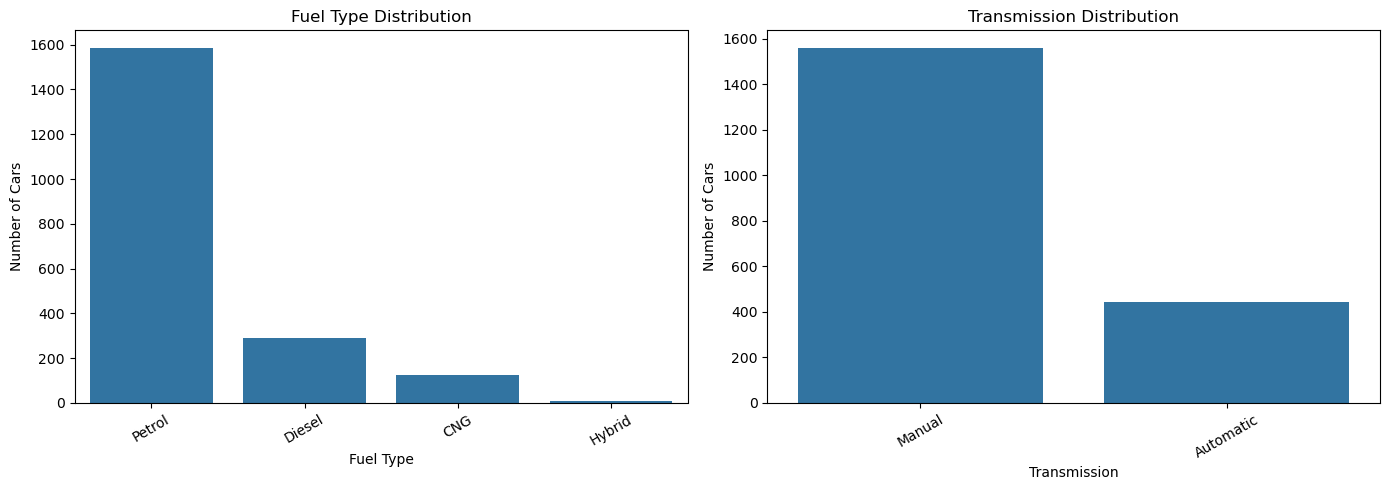

In [31]:
# Univariate Analysis: Fuel Type and Transmission
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fuel_counts = eda['fuel_type'].value_counts()
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, ax=axes[0])
axes[0].set_title('Fuel Type Distribution')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Number of Cars')
axes[0].tick_params(axis='x', rotation=30)

trans_counts = eda['transmission'].value_counts()
sns.barplot(x=trans_counts.index, y=trans_counts.values, ax=axes[1])
axes[1].set_title('Transmission Distribution')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Number of Cars')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 10.2 Bivariate Analysis — City, Brand and Price Relationships

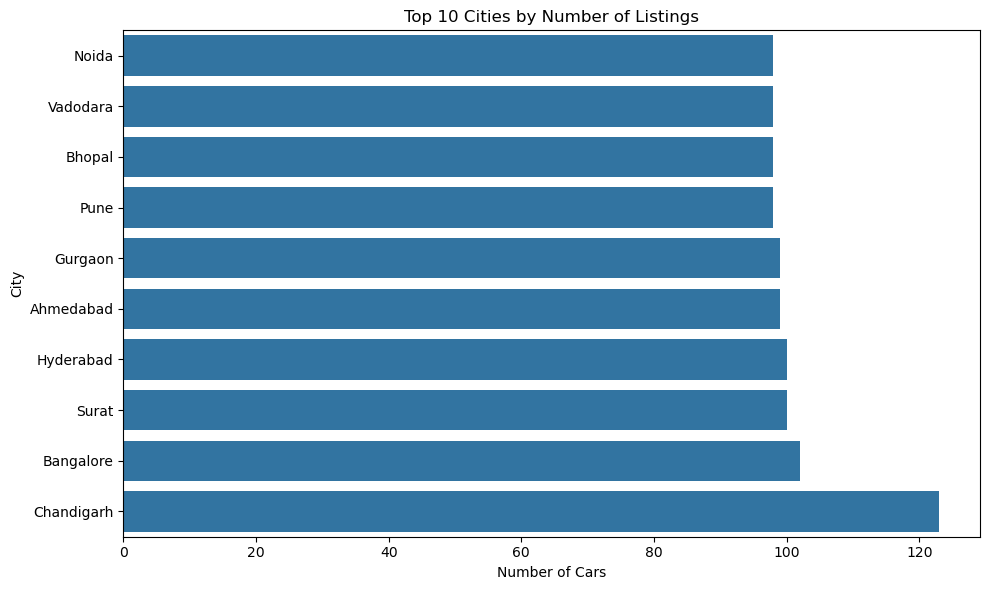

,Number_of_Cars
City,
Chandigarh,123
Bangalore,102
Hyderabad,100
Surat,100
Gurgaon,99
Ahmedabad,99
Noida,98
Vadodara,98
Bhopal,98


In [32]:
# City-wise listing volume — Top 10 cities
city_counts = eda['City'].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title('Top 10 Cities by Number of Listings')
plt.xlabel('Number of Cars')
plt.ylabel('City')
plt.tight_layout()
plt.show()

display(eda['City'].value_counts().head(10).rename('Number_of_Cars').to_frame())


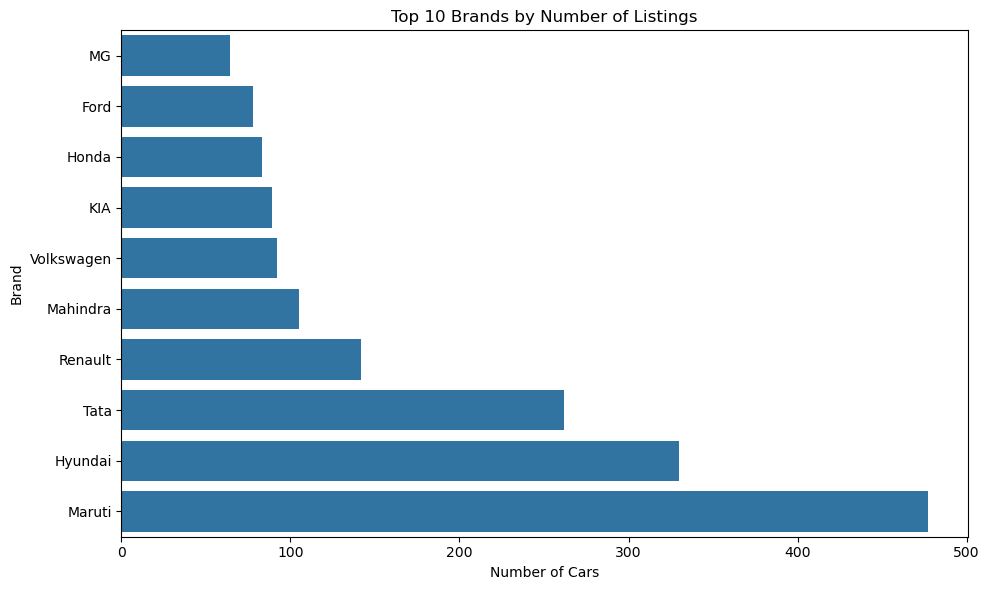

,Number_of_Cars
brand,
Maruti,477
Hyundai,330
Tata,262
Renault,142
Mahindra,105
Volkswagen,92
KIA,89
Honda,83
Ford,78


In [33]:
# Brand-wise listing volume — Top 10 brands
brand_counts = eda['brand'].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=brand_counts.values, y=brand_counts.index)
plt.title('Top 10 Brands by Number of Listings')
plt.xlabel('Number of Cars')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

display(eda['brand'].value_counts().head(10).rename('Number_of_Cars').to_frame())


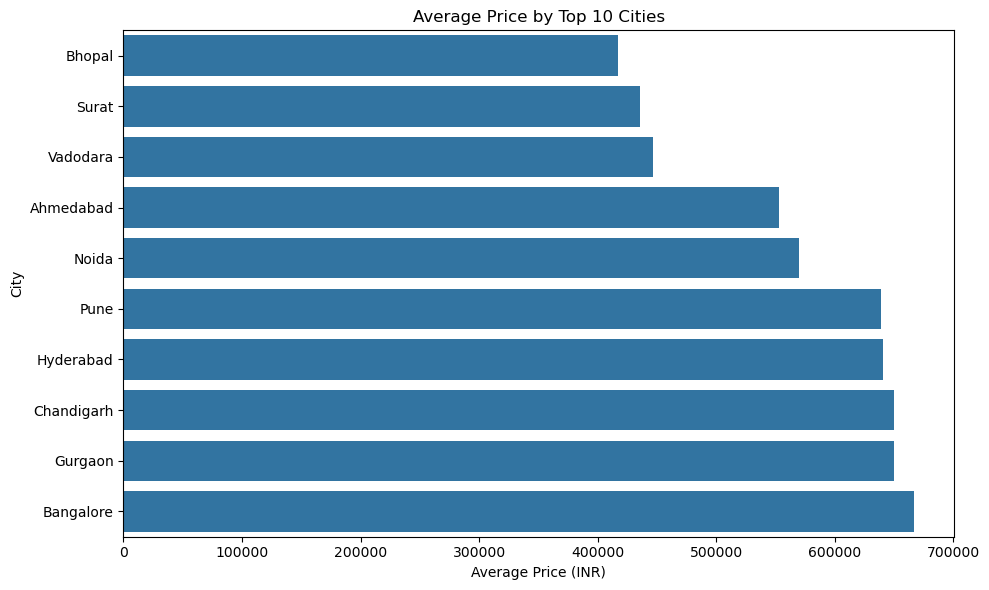

In [34]:
# Average price by city — Top 10 cities by listing volume
top_cities = eda['City'].value_counts().head(10).index
city_avg_price = (
    eda[eda['City'].isin(top_cities)]
    .groupby('City')['Price_INR']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_avg_price.values, y=city_avg_price.index)
plt.title('Average Price by Top 10 Cities')
plt.xlabel('Average Price (INR)')
plt.ylabel('City')
plt.tight_layout()
plt.show()


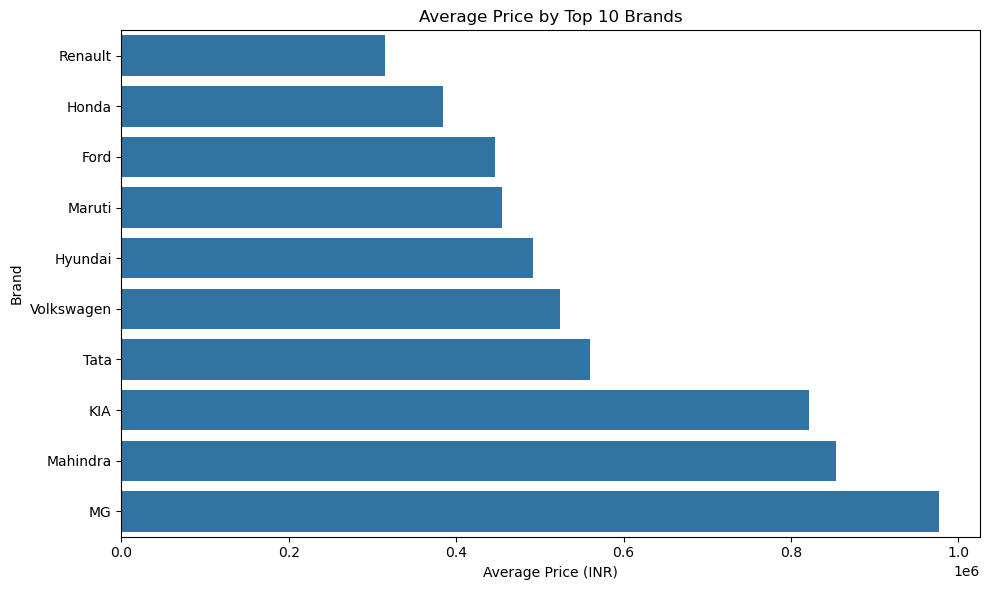

In [35]:
# Average price by brand — Top 10 brands by listing volume
top_brands = eda['brand'].value_counts().head(10).index
brand_avg_price = (
    eda[eda['brand'].isin(top_brands)]
    .groupby('brand')['Price_INR']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
sns.barplot(x=brand_avg_price.values, y=brand_avg_price.index)
plt.title('Average Price by Top 10 Brands')
plt.xlabel('Average Price (INR)')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()


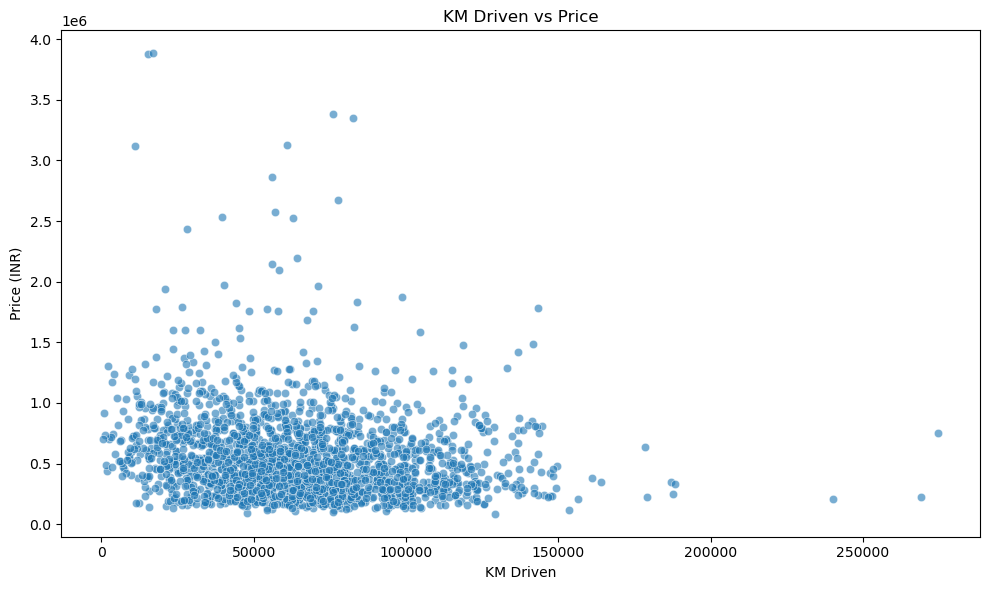

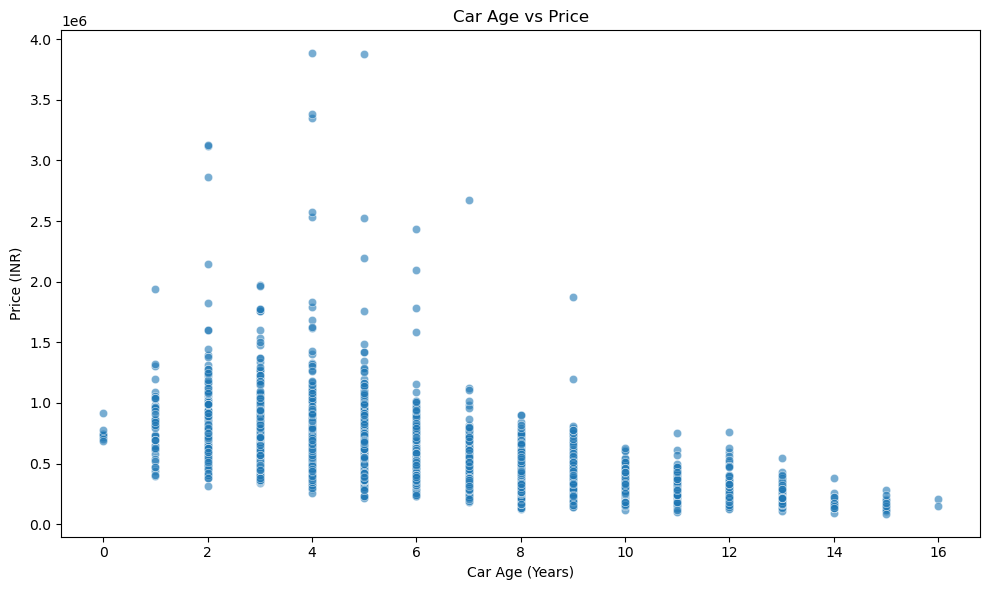

In [36]:
# KM Driven vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda, x='KM', y='Price_INR', alpha=0.6)
plt.title('KM Driven vs Price')
plt.xlabel('KM Driven')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

# Car Age vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda, x='Car_Age', y='Price_INR', alpha=0.6)
plt.title('Car Age vs Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()


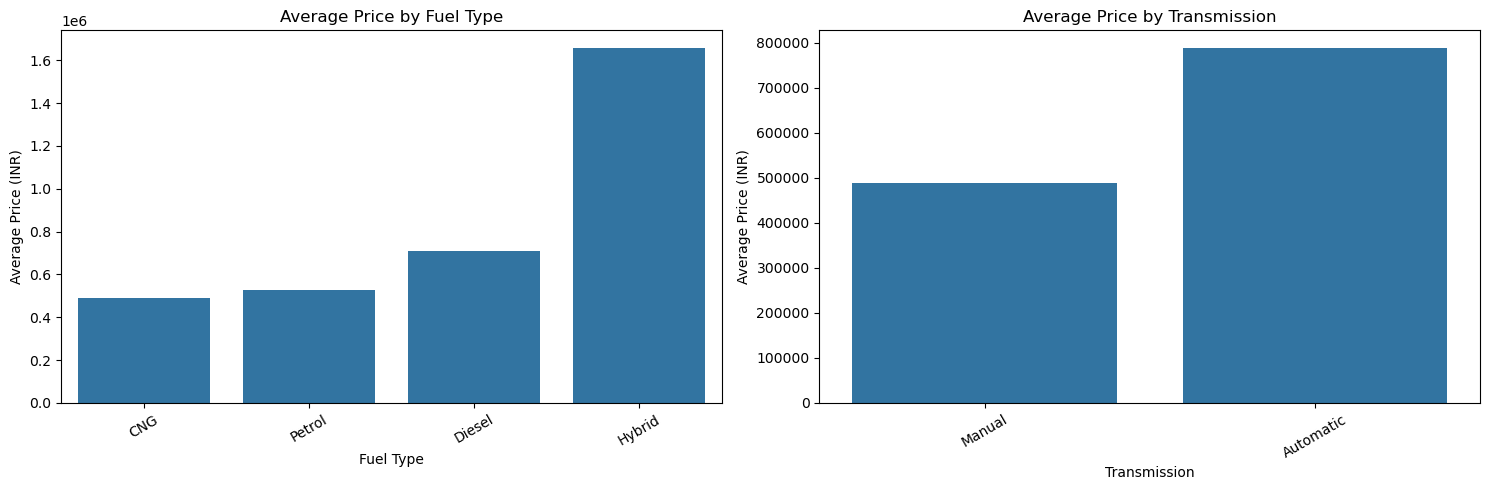

In [37]:
# Average price by fuel type and transmission
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fuel_price = eda.groupby('fuel_type')['Price_INR'].mean().sort_values()
sns.barplot(x=fuel_price.index, y=fuel_price.values, ax=axes[0])
axes[0].set_title('Average Price by Fuel Type')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Average Price (INR)')
axes[0].tick_params(axis='x', rotation=30)

trans_price = eda.groupby('transmission')['Price_INR'].mean().sort_values()
sns.barplot(x=trans_price.index, y=trans_price.values, ax=axes[1])
axes[1].set_title('Average Price by Transmission')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Average Price (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 10.3 Multivariate Analysis — Brand, Fuel, Transmission and Price

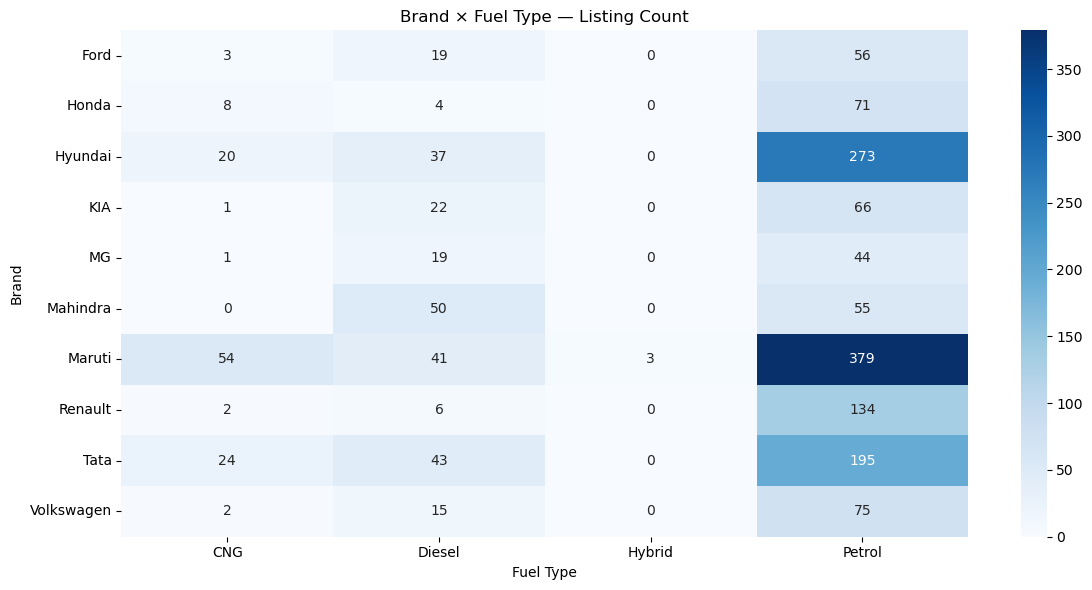

In [38]:
# Brand x Fuel Type heatmap — listing counts for top 10 brands
top_brands = eda['brand'].value_counts().head(10).index
brand_fuel = pd.crosstab(
    eda.loc[eda['brand'].isin(top_brands), 'brand'],
    eda.loc[eda['brand'].isin(top_brands), 'fuel_type']
)

plt.figure(figsize=(12, 6))
sns.heatmap(brand_fuel, annot=True, fmt='d', cmap='Blues')
plt.title('Brand × Fuel Type — Listing Count')
plt.xlabel('Fuel Type')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()


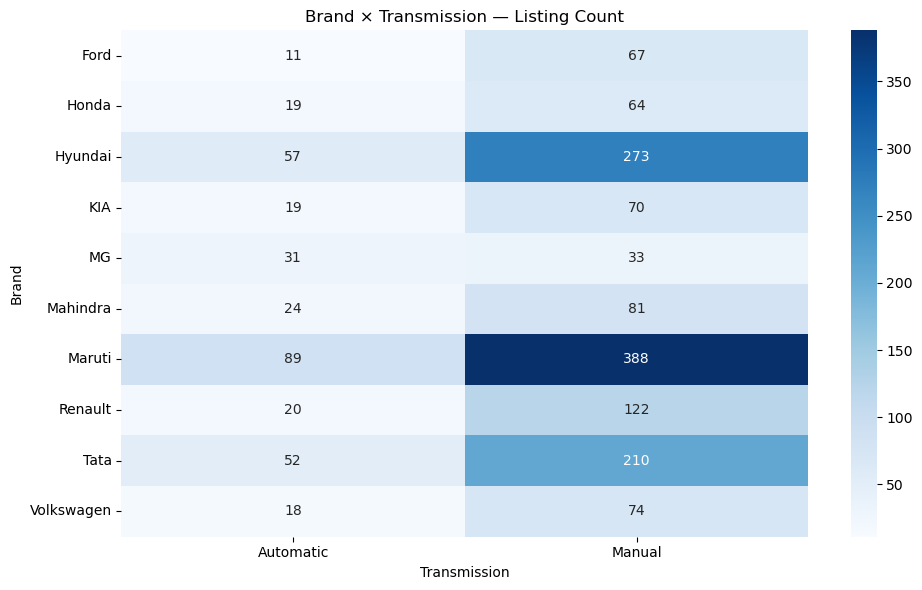

In [39]:
# Brand x Transmission heatmap — listing counts for top 10 brands
brand_trans = pd.crosstab(
    eda.loc[eda['brand'].isin(top_brands), 'brand'],
    eda.loc[eda['brand'].isin(top_brands), 'transmission']
)

plt.figure(figsize=(10, 6))
sns.heatmap(brand_trans, annot=True, fmt='d', cmap='Blues')
plt.title('Brand × Transmission — Listing Count')
plt.xlabel('Transmission')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()


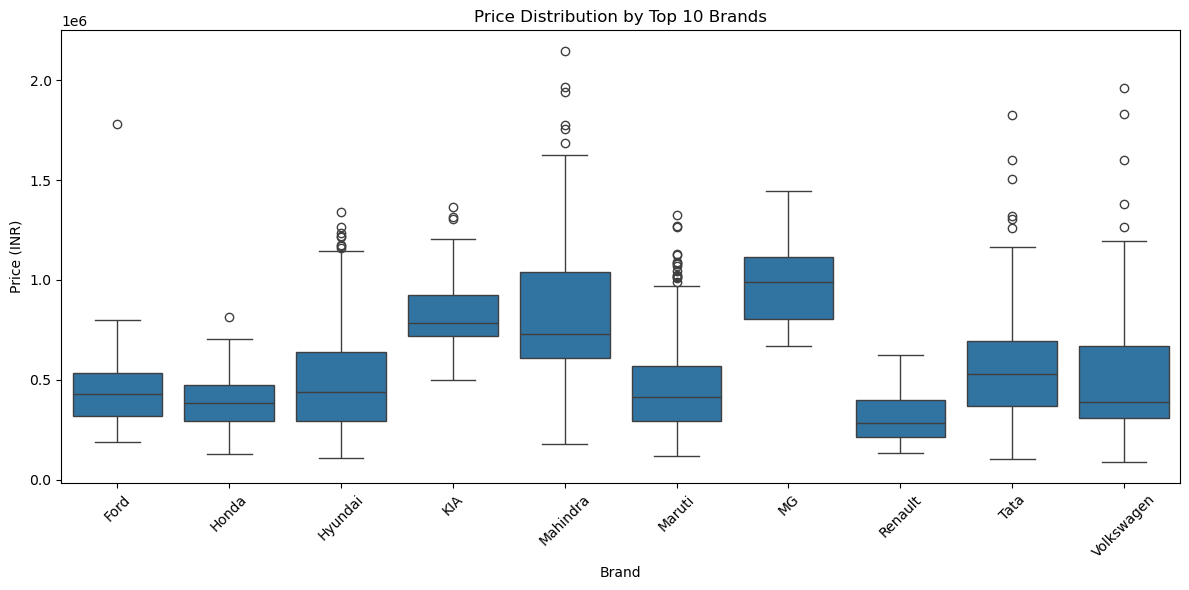

In [40]:
# Price distribution across top brands
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=eda[eda['brand'].isin(top_brands)],
    x='brand',
    y='Price_INR'
)
plt.title('Price Distribution by Top 10 Brands')
plt.xlabel('Brand')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


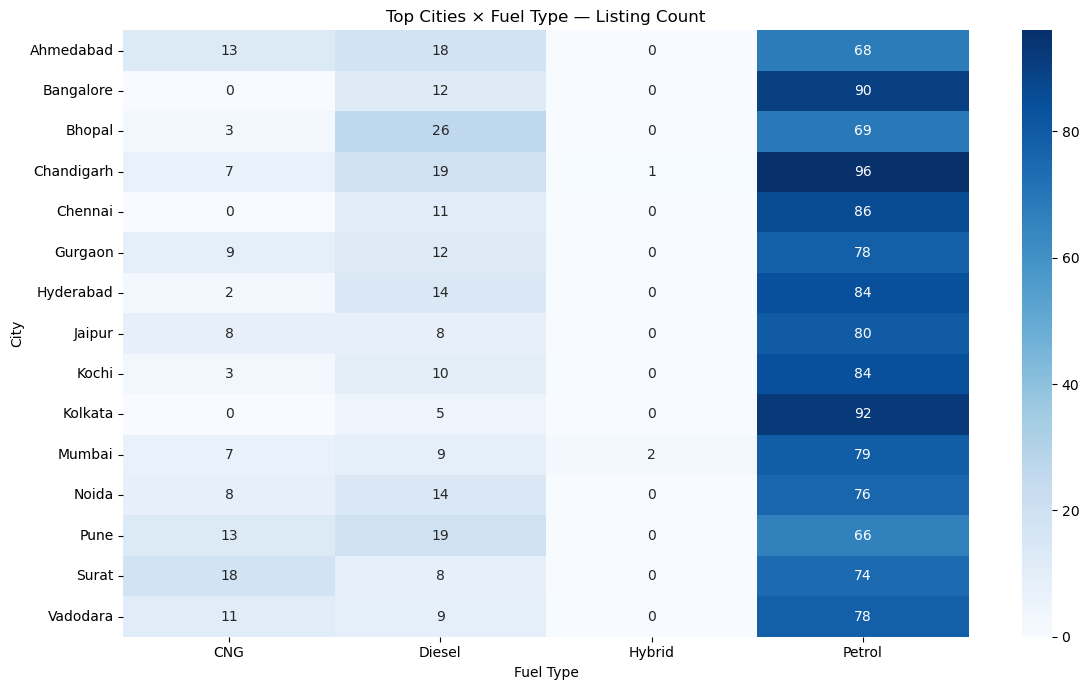

In [41]:
# City x Fuel Type heatmap — listing counts
city_fuel = pd.crosstab(eda['City'], eda['fuel_type'])
top_city_order = eda['City'].value_counts().head(15).index
city_fuel = city_fuel.loc[city_fuel.index.intersection(top_city_order)]

plt.figure(figsize=(12, 7))
sns.heatmap(city_fuel, annot=True, fmt='d', cmap='Blues')
plt.title('Top Cities × Fuel Type — Listing Count')
plt.xlabel('Fuel Type')
plt.ylabel('City')
plt.tight_layout()
plt.show()


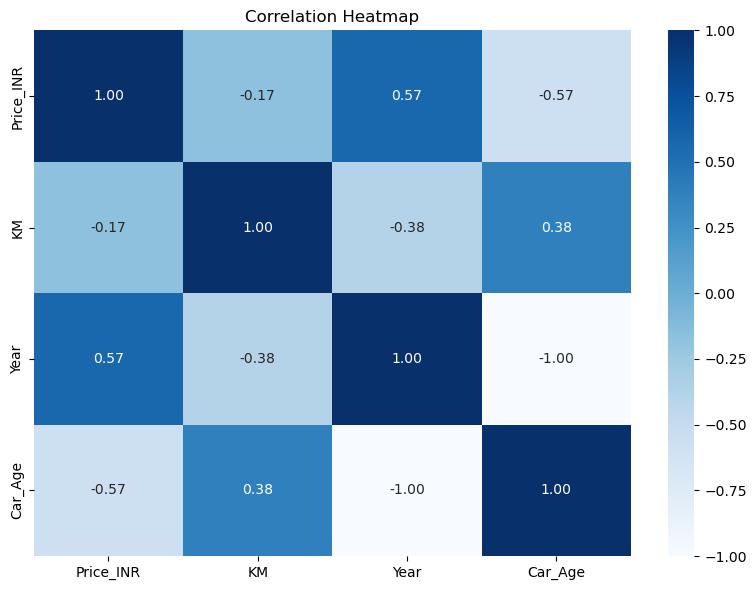

In [42]:
# Correlation heatmap for numerical analysis variables
corr_cols = [c for c in ['Price_INR', 'KM', 'Year', 'Car_Age'] if c in eda.columns]
corr = eda[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 10.4 EDA Summary for Presentation

Use the charts above for the PPT in this order:

1. **Univariate Analysis** — Price, KM, Car Age, Fuel Type, Transmission
2. **Bivariate Analysis** — City, Brand, Price relationships
3. **Multivariate Analysis** — Brand × Fuel, Brand × Transmission, Brand × Price, City × Fuel, Correlation
4. **Key Findings** — Fill only from the actual chart outputs after running the notebook.


🔑 KEY FINDINGS
2,004 used-car listings were analyzed across 30 cities.
Chandigarh recorded the highest number of listings in the collected dataset.
Maruti, Hyundai and Tata are among the major brands represented in the dataset.
The overall average used-car price is ~₹5.56 lakh, while the median is ~₹4.83 lakh.
Most listings are concentrated around moderate KM-driven and relatively newer vehicles.
Petrol cars form a significant share of the available listings, followed by other fuel types.
Manual transmission has a strong presence across the collected listings.
Car age and KM driven show a relationship with vehicle price, with newer/lower-usage cars generally appearing at higher price levels.
Price varies noticeably across cities, brands, fuel types and transmission types.